### Preamble:

In [1]:
import os
import random

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

In [2]:
# ── Reproducibility ────────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark     = False

g = torch.Generator()
g.manual_seed(SEED)

### Importing the Dataset:

In [3]:
main_path = "C:/Users/belmu/OneDrive/Escritorio/Lucas/Repositories/quant-finance-projects/quant-finance-projects/04_lstm_extended_assets"

In [4]:
df_stock_prices = pd.read_csv(main_path + r"/data/training_data_extended_clean.csv")

In [5]:
# Convert 'date' column to datetime:
df_stock_prices['date'] = pd.to_datetime(df_stock_prices['date'])

# Define max and min dates:
max_date = df_stock_prices['date'].max()
min_date = df_stock_prices['date'].min()
print(f"Data range: {min_date.date()} to {max_date.date()}")

all_columns = df_stock_prices.columns.tolist()
price_cols = [col for col in all_columns if col.endswith("_price")]
return_cols = [col for col in all_columns if col.endswith("_return")]
feature_cols = price_cols + return_cols

# Define split dates to match those ones in the paper:
train_end   = pd.Timestamp("2024-03-25")
val_end     = pd.Timestamp("2025-03-25")
test_end    = pd.Timestamp("2026-03-25")

# Training set: 2006-02-06 to 2010-12-31:
df_train = df_stock_prices[df_stock_prices['date'] <= train_end].reset_index(drop=True)

# Validation set: 2011-01-01 to 2015-12-31:
df_val   = df_stock_prices[(df_stock_prices['date'] > train_end) &
                           (df_stock_prices['date'] <= val_end)].reset_index(drop=True)

# Test set: 2016-01-01 to 2020-04-30:
df_test  = df_stock_prices[(df_stock_prices['date'] > val_end) &
                           (df_stock_prices['date'] <= test_end)].reset_index(drop=True)


Data range: 2016-01-05 to 2026-03-26


In [6]:
df_train.head()

,date,communication_services_price,consumer_discretionary_price,consumer_staples_price,energy_price,financials_price,health_care_price,industrials_price,materials_price,real_estate_price,...,real_estate_return,technology_return,utilities_return,emerging_return,developed_return,long_bond_return,gold_return,copper_return,agriculture_return,oil_return
0,2016-01-05,1.010510,0.998843,1.006551,1.003486,1.004130,1.004846,1.002734,0.999428,1.030009,...,0.030009,-0.002637,0.006997,0.002394,-0.001130,-0.004012,0.002819,0.000000,-0.000797,-0.029144
1,2016-01-06,1.006249,0.988719,1.003145,0.965139,0.988642,0.996658,0.987241,0.973112,1.020314,...,-0.009413,-0.012692,-0.001895,-0.019108,-0.018106,0.013500,0.014441,0.003608,-0.019681,-0.051595
2,2016-01-07,0.985513,0.968470,0.991090,0.941235,0.960764,0.976437,0.960355,0.946796,1.001385,...,-0.018552,-0.029459,-0.006329,-0.030844,-0.018824,0.001826,0.014140,-0.033070,-0.019805,-0.020772
3,2016-01-08,0.977844,0.958056,0.983491,0.929283,0.945792,0.961731,0.950558,0.937071,0.988458,...,-0.012909,-0.007726,-0.000637,-0.010888,-0.012529,0.004396,-0.004428,-0.000751,-0.006366,-0.010101
4,2016-01-11,0.982389,0.965577,0.992662,0.909363,0.947341,0.950368,0.951242,0.921053,0.994460,...,0.006072,0.006118,0.005736,-0.000423,0.004362,-0.010889,-0.008895,-0.020082,-0.008078,-0.056122


In [7]:
df_val.head()

,date,communication_services_price,consumer_discretionary_price,consumer_staples_price,energy_price,financials_price,health_care_price,industrials_price,materials_price,real_estate_price,...,real_estate_return,technology_return,utilities_return,emerging_return,developed_return,long_bond_return,gold_return,copper_return,agriculture_return,oil_return
0,2024-03-26,1.817498,2.594157,1.875786,2.162351,2.072793,2.355615,2.746411,2.514302,1.652816,...,-0.004172,-0.004176,-0.011229,-0.000769,0.001495,0.002793,0.003234,-0.004377,-0.002153,-0.006044
1,2024-03-27,1.826303,2.624241,1.895440,2.182271,2.097574,2.387032,2.790385,2.550343,1.694829,...,0.025419,0.005169,0.027722,0.001797,0.006610,0.009865,0.007241,0.001199,0.017839,0.002846
2,2024-03-28,1.823605,2.616141,1.898061,2.206175,2.108931,2.387199,2.790841,2.557208,1.705448,...,0.006265,-0.002135,0.006825,0.003587,-0.002118,-0.000805,0.012900,0.002794,0.002120,0.015740
3,2024-04-01,1.832268,2.596760,1.882862,2.222610,2.097574,2.366979,2.769424,2.551487,1.675439,...,-0.017596,0.002723,-0.006133,0.001787,-0.003821,-0.018519,0.010208,0.010748,-0.007193,0.011940
4,2024-04-02,1.833262,2.558288,1.873166,2.253486,2.086732,2.330047,2.756437,2.541762,1.656971,...,-0.011022,-0.009600,0.001949,0.003058,-0.006179,-0.005508,0.014772,0.005514,-0.003552,0.014058


In [8]:
df_test.head()

,date,communication_services_price,consumer_discretionary_price,consumer_staples_price,energy_price,financials_price,health_care_price,industrials_price,materials_price,real_estate_price,...,real_estate_return,technology_return,utilities_return,emerging_return,developed_return,long_bond_return,gold_return,copper_return,agriculture_return,oil_return
0,2025-03-26,2.163329,2.916691,2.037474,2.262450,2.556531,2.376504,3.003873,2.432494,1.853647,...,0.005258,-0.022292,0.006684,-0.005963,-0.012010,-0.006520,-0.000826,0.002142,0.002860,0.008019
1,2025-03-27,2.147138,2.918426,2.060535,2.240538,2.551368,2.380180,2.987924,2.431350,1.849030,...,-0.002491,-0.009233,-0.000266,0.004845,0.001196,-0.002930,0.013406,-0.024122,0.007954,0.000796
2,2025-03-28,2.081665,2.827885,2.050577,2.229582,2.502323,2.372828,2.926407,2.386728,1.848107,...,-0.000499,-0.024249,0.007439,-0.018599,-0.011346,0.013752,0.007412,-0.000313,-0.016528,-0.009406
3,2025-03-31,2.085783,2.833960,2.082547,2.254482,2.532783,2.397393,2.946913,2.412471,1.867959,...,0.010742,0.000487,0.011076,-0.001638,-0.008053,0.009971,0.014363,-0.010955,0.003028,0.034238
4,2025-04-01,2.099702,2.863465,2.085692,2.267928,2.529685,2.353443,2.963545,2.421625,1.868883,...,0.000494,0.007306,0.002608,0.003281,0.003450,0.008610,-0.001978,-0.002532,0.001509,-0.003233


In [9]:
summary = pd.concat({
    'Train': df_train[return_cols].describe(),
    'Validation': df_val[return_cols].describe()
}, axis=1)

# Reorder columns so each asset shows Train/Validation next to each other
summary = summary.swaplevel(axis=1).sort_index(axis=1)

summary

agriculture_return             communication_services_return  \
                   Train  Validation                         Train   
count        2069.000000  250.000000                   2069.000000   
mean            0.000368   -0.000149                      0.000380   
std             0.011849    0.009015                      0.013422   
min            -0.117699   -0.030684                     -0.114164   
25%            -0.005054   -0.005839                     -0.005977   
50%             0.000584    0.000216                      0.000730   
75%             0.006643    0.005056                      0.007364   
max             0.082942    0.025433                      0.087484   

                  consumer_discretionary_return              \
       Validation                         Train  Validation   
count  250.000000                   2069.000000  250.000000   
mean     0.000796                      0.000554    0.000607   
std      0.010370                      0.013680    0.012707   
min     -0.034060                     -0.105361   -0.045074   
25%     -0.004950                     -0.005288   -0.006130   
50%      0.001944                      0.001231    0.001218   
75%      0.007632                      0.007196    0.009014   
max      0.029805                      0.093765    0.037359   

      consumer_staples_return             copper_return              ...  \
                        Train  Validation         Train  Validation  ...   
count             2069.000000  250.000000   2069.000000  250.000000  ...   
mean                 0.000351    0.000295      0.000385    0.001166  ...   
std                  0.009744    0.006994      0.013997    0.015169  ...   
min                 -0.093776   -0.021684     -0.079917   -0.057999  ...   
25%                 -0.003699   -0.004042     -0.007544   -0.008411  ...   
50%                  0.000515    0.000494      0.000000    0.001436  ...   
75%                  0.005126    0.004825      0.008561    0.010344  ...   
max                  0.111773    0.027052      0.109483    0.055809  ...   

      materials_return               oil_return              \
                 Train  Validation        Train  Validation   
count      2069.000000  250.000000  2069.000000  250.000000   
mean          0.000538   -0.000103     0.000267   -0.000012   
std           0.013510    0.008922     0.025249    0.016861   
min          -0.131156   -0.028331    -0.253150   -0.051192   
25%          -0.006143   -0.006212    -0.011720   -0.010463   
50%           0.000814   -0.000235     0.001552   -0.000668   
75%           0.007665    0.006063     0.013624    0.011254   
max           0.117440    0.026021     0.166667    0.044050   

      real_estate_return             technology_return              \
                   Train  Validation             Train  Validation   
count        2069.000000  250.000000       2069.000000  250.000000   
mean            0.000331    0.000476          0.000933    0.000327   
std             0.013110    0.010443          0.015135    0.015136   
min            -0.099476   -0.040950         -0.139960   -0.049002   
25%            -0.005803   -0.005722         -0.005547   -0.007008   
50%             0.000841    0.000944          0.001297    0.001821   
75%             0.006734    0.007074          0.008386    0.010152   
max             0.087699    0.026575          0.117515    0.042377   

      utilities_return              
                 Train  Validation  
count      2069.000000  250.000000  
mean          0.000393    0.000895  
std           0.012306    0.010023  
min          -0.100240   -0.026621  
25%          -0.005378   -0.005757  
50%           0.001016    0.001174  
75%           0.006454    0.007542  
max           0.107544    0.027722  

[8 rows x 36 columns]

### Constructing the dataset:

In [10]:
# Hyperparameters:
seq_len = 50                        # Lookback window.
batch_size = 64                     # Batch size for DataLoader.
num_assets = len(return_cols)       # Number of assets to allocate to.
input_dim = len(feature_cols)       # Number of features per date.
hidden_size = 64                    # LSTM hidden size.
num_epochs = 10                     # Number of training epochs.
num_layers = 1                      # Number of one-directional layers in the LSTM.

##### Building (X, Y) Sequences for LSTM Training

For each time index `t` starting at `seq_len`:
1. **Input (`X_t`)** → the previous `seq_len` rows  
   $$
   X_t = [\text{features}_{t-\text{seq\_len}}, \dots, \text{features}_{t-1}]
   $$
   with shape `(seq_len, input_dim)`.
2. **Target (`Y_t`)** → the returns on the following day  
   $$
   Y_t = \text{returns}_t
   $$
   with shape `(num_assets,)`.

Rolling this window across the dataset yields:
$$
X \in \mathbb{R}^{N \times \text{seq\_len} \times \text{input\_dim}}, \quad
Y \in \mathbb{R}^{N \times \text{num\_assets}}
$$

where $N$ represents the number of training samples you end up with after constructing all rolling windows.

In [11]:
def make_xy(df, seq_len, feature_cols, return_cols):
    X, Y = [], []
    for t in range(seq_len, len(df)):
        # Features: last seq_len rows. Note: iloc[t-seq_len:t] includes prices_{t-1} and returns_{t-2->t_1}.
        X.append(df[feature_cols].iloc[t-seq_len:t].values)
        # Label: next-day returns. Note: iloc[t] includes prices_{t} and returns_{t-1->t}.
        Y.append(df[return_cols].iloc[t].values)
    return np.array(X), np.array(Y)

X_train, Y_train = make_xy(df_train, seq_len, feature_cols=feature_cols, return_cols=return_cols)
X_val,   Y_val   = make_xy(df_val,   seq_len, feature_cols=feature_cols, return_cols=return_cols)
X_test,  Y_test  = make_xy(df_test,  seq_len, feature_cols=feature_cols, return_cols=return_cols)

In [12]:
# Convert numpy arrays to torch tensors:
X_train_t = torch.tensor(X_train, dtype=torch.float32)
Y_train_t = torch.tensor(Y_train, dtype=torch.float32)
X_val_t   = torch.tensor(X_val,   dtype=torch.float32)
Y_val_t   = torch.tensor(Y_val,   dtype=torch.float32)
X_test_t  = torch.tensor(X_test,  dtype=torch.float32)
Y_test_t  = torch.tensor(Y_test,  dtype=torch.float32)

# Create TensorDatasets:
train_ds = TensorDataset(X_train_t, Y_train_t)
val_ds   = TensorDataset(X_val_t,   Y_val_t)
test_ds  = TensorDataset(X_test_t,  Y_test_t)

# DataLoader with batching and shuffling
train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=False, generator=g)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, drop_last=False)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, drop_last=False)

### Constructing the Model: LSTM → Dense → Softmax model

In [13]:
class PortfolioNet(nn.Module):
    def __init__(self, input_dim, hidden_size, num_assets, num_layers):
        """
        input_dim   = number of features at each time step (e.g. 8: 4 prices + 4 returns)
        hidden_size = number of hidden units inside the LSTM (e.g. 64)
        num_assets  = number of portfolio weights we want as output (e.g. 4 assets)
        """
        super().__init__()   # initialize the parent nn.Module class

        # Define an LSTM layer
        # batch_first=True means input shape is [batch, seq_len, input_dim]
        self.lstm = nn.LSTM(input_size=input_dim,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)

        # Define a fully connected (dense) layer: Maps from the hidden_size (e.g. 64)-> number of assets (e.g. 4)
        self.fc = nn.Linear(hidden_size, num_assets)

    def forward(self, x):
        """
        Forward pass: defines how input data flows through the network

        x: [batch, seq_len, input_dim]
        Example: if batch_size=32, seq_len=50, input_dim=8 → shape [32, 50, 8]
        """

        # Pass the input sequence through the LSTM
        _, (h_n, _) = self.lstm(x) 

        # Picks the hidden state from the last layer, last time step 
        h_last = h_n[-1] # Shape becomes [batch, hidden_size]

        # Pass the last hidden state through the fully connected layer
        logits = self.fc(h_last)   #  One logit (raw score) [batch, hidden_size]→[batch, num_assets]

        # Apply softmax so that the outputs become portfolio weights:
        # - Each weight is >= 0
        # - All weights sum to 1
        weights = F.softmax(logits, dim=-1) # -> shape: [batch, num_assets]

        return weights

#### Custom sharpe ratio loss:

In [14]:
def sharpe_loss_batch(weights, next_day_returns):
    '''
    Compute the negative Sharpe ratio for a batch of portfolio weights and realized returns.
    The model is trained to maximize the Sharpe ratio by minimizing this loss.

    Arguments:

    weights: [batch, num_assets]
        - portfolio weights predicted by the model for each example in the batch
        - each row sums to 1 (because of softmax)
        - Example (batch=3, num_assets=4):
          [[0.2, 0.3, 0.1, 0.4],
           [0.1, 0.5, 0.2, 0.2],
           [0.25, 0.25, 0.25, 0.25]]

    next_day_returns: [batch, num_assets]
        - actual realised asset returns for the next day, one row per example
        - Example (same batch=3, num_assets=4):
          [[ 0.01, -0.005, 0.002, 0.003],
           [-0.002, 0.004, 0.001, -0.001],
           [ 0.010, 0.012, -0.003, 0.005]]

    Note:  The loss averages returns across the batch, which may contain non-contiguous dates
    (if DataLoader shuffle=True). This yields an *expected* Sharpe across random windows,
    not the realized time-series Sharpe of a continuous strategy.
    '''
    # Compute daily portfolio returns: R_t = sum_i w_{t-1,i} * r_{t,i}
    port_rets = (weights * next_day_returns).sum(dim=1)  
    # Compute the expected portfolio return and std over this batch:
    mean_R = port_rets.mean()                            
    std_R = port_rets.std(unbiased=False) + 1e-8
    # Sharpe ratio (no risk-free rate adjustment)         
    sharpe = mean_R / std_R
                                 
    return -sharpe

### Training:

In [15]:
# Initialize model and optimizer
model = PortfolioNet(input_dim=input_dim,
                     hidden_size=hidden_size,
                     num_assets=num_assets,
                     num_layers=num_layers)

In [16]:
# ── Training function ──────────────────────────────────────────────────────────
def train_model(model, train_loader, val_loader,
                max_epochs=200, patience=20, lr=1e-3):
 
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode="max", factor=0.5, patience=10,
    )
 
    best_val_sharpe   = -np.inf
    epochs_no_improve = 0
    best_model_state  = None
    train_history, val_history = [], []
 
    for epoch in range(max_epochs):
 
        # ── Step 1: Train as usual (don't bother collecting returns) ──
        model.train()
        for X_batch, Y_batch in train_loader:
            optimizer.zero_grad()
            weights = model(X_batch)
            loss = sharpe_loss_batch(weights, Y_batch)
            loss.backward()
            optimizer.step()

        # ── Step 2: Evaluate cleanly with the FINISHED model ──
        model.eval()
        all_train_rets = []
        with torch.no_grad():
            for X_batch, Y_batch in train_loader:
                weights = model(X_batch)      # every batch uses the SAME final θ
                all_train_rets.append((weights * Y_batch).sum(dim=1))

        all_train_rets = torch.cat(all_train_rets)
        train_sharpe = (all_train_rets.mean() /
                    (all_train_rets.std(unbiased=False) + 1e-8)).item() * (252**0.5)
        train_history.append(train_sharpe)
 
        # Validation
        all_val_rets = []
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                weights = model(X_batch)
                all_val_rets.append((weights * Y_batch).sum(dim=1))
 
        all_val_rets = torch.cat(all_val_rets)
        val_sharpe   = (all_val_rets.mean() /
                       (all_val_rets.std(unbiased=False) + 1e-8)).item() * (252 ** 0.5)
        val_history.append(val_sharpe)
 
        scheduler.step(val_sharpe)
 
        # Checkpoint
        if val_sharpe > best_val_sharpe:
            best_val_sharpe   = val_sharpe
            best_model_state  = {k: v.clone() for k, v in model.state_dict().items()}
            epochs_no_improve = 0
            marker = " ✓"
        else:
            epochs_no_improve += 1
            marker = ""
 
        print(f"Epoch {epoch+1:>3} | "
              f"Train: {train_sharpe:+.4f} | "
              f"Val: {val_sharpe:+.4f} | "
              f"Best: {best_val_sharpe:+.4f} | "
              f"No improve: {epochs_no_improve:>2}/{patience} | "
              f"LR: {optimizer.param_groups[0]['lr']:.2e}"
              f"{marker}")
 
        if epochs_no_improve >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}.")
            break
 
    model.load_state_dict(best_model_state)
    return best_model_state, train_history, val_history
 

In [17]:
best_state, train_history, val_history = train_model(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    max_epochs=200,
    patience=20,
    lr=1e-3
)

Epoch   1 | Train: +0.7318 | Val: +1.2261 | Best: +1.2261 | No improve:  0/20 | LR: 1.00e-03 ✓
Epoch   2 | Train: +0.7710 | Val: +1.1877 | Best: +1.2261 | No improve:  1/20 | LR: 1.00e-03
Epoch   3 | Train: +0.8577 | Val: +1.1604 | Best: +1.2261 | No improve:  2/20 | LR: 1.00e-03
Epoch   4 | Train: +0.9761 | Val: +0.9949 | Best: +1.2261 | No improve:  3/20 | LR: 1.00e-03
Epoch   5 | Train: +1.0051 | Val: +0.7707 | Best: +1.2261 | No improve:  4/20 | LR: 1.00e-03
Epoch   6 | Train: +1.0557 | Val: +1.1820 | Best: +1.2261 | No improve:  5/20 | LR: 1.00e-03
Epoch   7 | Train: +1.0216 | Val: +0.6434 | Best: +1.2261 | No improve:  6/20 | LR: 1.00e-03
Epoch   8 | Train: +1.0443 | Val: +0.9911 | Best: +1.2261 | No improve:  7/20 | LR: 1.00e-03
Epoch   9 | Train: +1.0621 | Val: +1.0911 | Best: +1.2261 | No improve:  8/20 | LR: 1.00e-03
Epoch  10 | Train: +1.0534 | Val: +0.8902 | Best: +1.2261 | No improve:  9/20 | LR: 1.00e-03
Epoch  11 | Train: +1.0785 | Val: +1.3163 | Best: +1.3163 | No impro

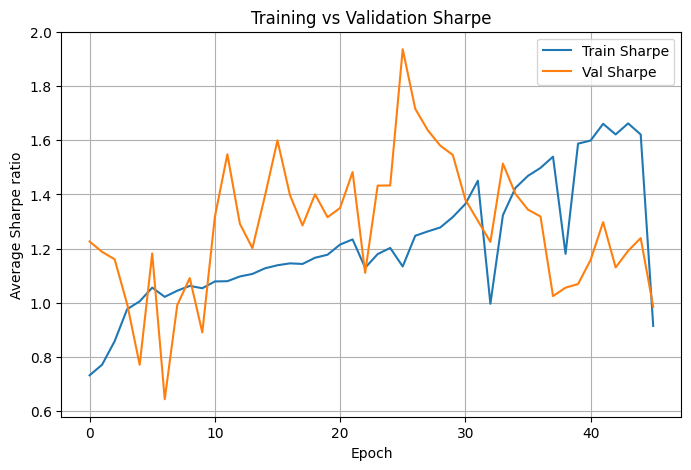

In [18]:
plt.figure(figsize=(8,5))
plt.plot(train_history, label="Train Sharpe")
plt.plot(val_history, label="Val Sharpe")
plt.xlabel("Epoch")
plt.ylabel("Average Sharpe ratio")
plt.title("Training vs Validation Sharpe")
plt.legend()
plt.grid(True)
plt.show()

### Validation Sharpe ratio:

In [19]:
model.eval()
all_weights, all_returns = [], []

with torch.no_grad():
    for X_batch, Y_batch in val_loader:
        w = model(X_batch)
        all_weights.append(w)
        all_returns.append(Y_batch)

### Download the Benchmark portfolio:

In [20]:
# Download actual benchmark data for the full date range
bench_raw = yf.download(["^GSPC", "AGG"], start="2016-01-01", end="2026-03-26")["Close"]
bench_raw = bench_raw.rename(columns={"^GSPC": "SP500", "AGG": "AGG"})
bench_raw = bench_raw.dropna()

# Compute daily returns
bench_returns = bench_raw.pct_change().dropna()

C:\Users\belmu\AppData\Local\Temp\ipykernel_34840\1864268422.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  bench_raw = yf.download(["^GSPC", "AGG"], start="2016-01-01", end="2026-03-26")["Close"]
[*********************100%***********************]  2 of 2 completed


In [21]:
# --- Concatenate weights and realized returns ---
W = torch.cat(all_weights).numpy()   # (T, 4) portfolio weights
R = torch.cat(all_returns).numpy()   # (T, 4) realized next-day asset returns

# --- Portfolio daily returns ---
port_rets = (W * R).sum(axis=1)

# Get the dates that correspond to our evaluation samples
eval_dates = df_val['date'].iloc[seq_len:].values
# Match benchmark returns to those exact dates
bench_df = bench_returns.loc[bench_returns.index.isin(pd.to_datetime(eval_dates))]
# Verify alignment
assert len(bench_df) == len(port_rets), (
    f"Date mismatch: {len(bench_df)} benchmark rows vs {len(port_rets)} portfolio rows. "
    f"Some trading days may be missing from Yahoo data."
)

sp500_rets = bench_df["SP500"].values
agg_rets   = bench_df["AGG"].values
bench_rets = 0.25 * sp500_rets + 0.75 * agg_rets

# --- Cumulative growth ---
initial_capital = 100
cum_growth = (1 + port_rets).cumprod()
cum_sp500  = (1 + sp500_rets).cumprod()
cum_bench = (1 + bench_rets).cumprod()
final_value  = initial_capital * cum_growth[-1]
final_sp500  = initial_capital * cum_sp500[-1]
final_bench = initial_capital * cum_bench[-1]

# --- Time stats ---
n_days = len(port_rets)
n_years = n_days / 252  # assuming 252 trading days per year

# --- DAILY STATISTICS ---
port_mean_daily = port_rets.mean()
port_std_daily  = port_rets.std()
sp_mean_daily   = sp500_rets.mean()
sp_std_daily    = sp500_rets.std()
bench_mean_daily = bench_rets.mean()
bench_std_daily  = bench_rets.std()


# --- SHARPE RATIOS ---
port_sharpe_daily  = port_mean_daily / port_std_daily
sp500_sharpe_daily = sp_mean_daily / sp_std_daily
bench_sharpe_daily  = bench_mean_daily / bench_std_daily
port_sharpe_annual = port_sharpe_daily * np.sqrt(252)
sp500_sharpe_annual = sp500_sharpe_daily * np.sqrt(252)
bench_sharpe_annual = bench_sharpe_daily * np.sqrt(252)

# --- MAXIMUM DAILY LOSS ---
max_loss_port = port_rets.min()
max_loss_sp500 = sp500_rets.min()
max_loss_bench = bench_rets.min()

# --- DOWNSIDE DEVIATION (daily) ---
target_return = 0.0  # typically 0 or risk-free rate
downside_diff = np.minimum(0, port_rets - target_return)
port_downside_std = np.sqrt((downside_diff**2).mean())
downside_diff_sp = np.minimum(0, sp500_rets - target_return)
sp_downside_std = np.sqrt((downside_diff_sp**2).mean())
downside_diff_bench = np.minimum(0, bench_rets - target_return)
bench_downside_std = np.sqrt((downside_diff_bench**2).mean())

# --- SORTINO RATIOS (daily) ---
port_sortino_daily = port_mean_daily / port_downside_std
sp500_sortino_daily = sp_mean_daily / sp_downside_std
bench_sortino_daily = bench_mean_daily / bench_downside_std

# --- SORTINO RATIOS (annualized) ---
port_sortino_annual = port_sortino_daily * np.sqrt(252)
sp500_sortino_annual = sp500_sortino_daily * np.sqrt(252)
bench_sortino_annual = bench_sortino_daily * np.sqrt(252)

# --- PRINT RESULTS ---
print("\n=== Performance Summary in Validation Set===")
print(f"Initial investment:         ${initial_capital:.2f}")
print(f"Final portfolio value:      ${final_value:.2f}")
print(f"Final S&P 500 value:        ${final_sp500:.2f}")
print(f"Final Benchmark (75/25) value:     ${final_bench:.2f}")
print(f"Total trading days:         {n_days:,}  (~{n_years:.2f} years)")
print("--------------------------------------------------")
print(f"Portfolio Sharpe (daily):          {port_sharpe_daily:.4f}")
print(f"S&P 500 Sharpe (daily):            {sp500_sharpe_daily:.4f}")
print(f"Benchmark Sharpe (daily):          {bench_sharpe_daily:.4f}")
print("--------------------------------------------------")
print(f"Portfolio Sharpe (annual):         {port_sharpe_annual:.4f}")
print(f"S&P 500 Sharpe (annual):           {sp500_sharpe_annual:.4f}")
print(f"Benchmark Sharpe (annual):         {bench_sharpe_annual:.4f}")
print("--------------------------------------------------")
print(f"Portfolio Sortino (daily):         {port_sortino_daily:.4f}")
print(f"S&P 500 Sortino (daily):           {sp500_sortino_daily:.4f}")
print(f"Benchmark Sortino (daily):         {bench_sortino_daily:.4f}")
print("--------------------------------------------------")
print(f"Portfolio Sortino (annual):        {port_sortino_annual:.4f}")
print(f"S&P 500 Sortino (annual):          {sp500_sortino_annual:.4f}")
print(f"Benchmark Sortino (annual):        {bench_sortino_annual:.4f}")
print("--------------------------------------------------")
print(f"Max 1-day loss (Portfolio):        {max_loss_port*100:.2f}%")
print(f"Max 1-day loss (S&P 500):          {max_loss_sp500*100:.2f}%")
print(f"Max 1-day loss (Benchmark):        {max_loss_bench*100:.2f}%")
print("--------------------------------------------------")



=== Performance Summary in Validation Set===
Initial investment:         $100.00
Final portfolio value:      $120.20
Final S&P 500 value:        $107.89
Final Benchmark (75/25) value:     $105.08
Total trading days:         200  (~0.79 years)
--------------------------------------------------
Portfolio Sharpe (daily):          0.1220
S&P 500 Sharpe (daily):            0.0466
Benchmark Sharpe (daily):          0.0751
--------------------------------------------------
Portfolio Sharpe (annual):         1.9364
S&P 500 Sharpe (annual):           0.7399
Benchmark Sharpe (annual):         1.1925
--------------------------------------------------
Portfolio Sortino (daily):         0.1758
S&P 500 Sortino (daily):           0.0634
Benchmark Sortino (daily):         0.1094
--------------------------------------------------
Portfolio Sortino (annual):        2.7911
S&P 500 Sortino (annual):          1.0059
Benchmark Sortino (annual):        1.7364
------------------------------------------------

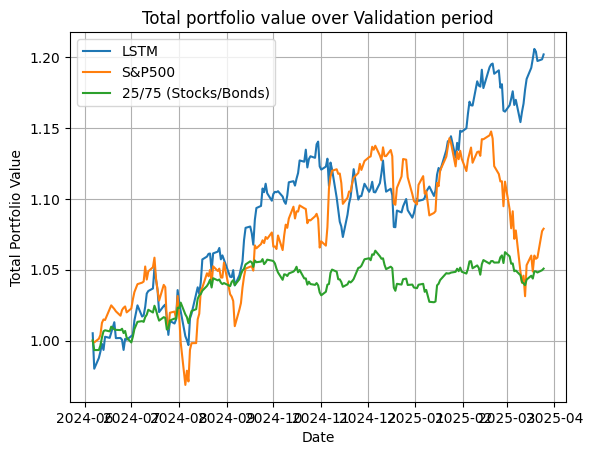

In [22]:
plt.plot(df_val['date'][seq_len:], cum_growth, label='LSTM')
plt.plot(df_val['date'][seq_len:], cum_sp500, label='S&P500')
plt.plot(df_val['date'][seq_len:], cum_bench, label='25/75 (Stocks/Bonds)')
plt.xlabel("Date")
plt.ylabel("Total Portfolio Value")
plt.title("Total portfolio value over Validation period")
plt.legend()
plt.grid(True)
plt.show()

### Test Sharpe ratio:

In [23]:
model.eval()
all_weights, all_returns = [], []

with torch.no_grad():
    for X_batch, Y_batch in test_loader:
        w = model(X_batch)
        all_weights.append(w)
        all_returns.append(Y_batch)

In [24]:
# --- Concatenate weights and realized returns ---
W = torch.cat(all_weights).numpy()   # (T, 4) portfolio weights
R = torch.cat(all_returns).numpy()   # (T, 4) realized next-day asset returns

# --- Portfolio daily returns ---
port_rets = (W * R).sum(axis=1)

# Get the dates that correspond to our evaluation samples
test_dates = df_test['date'].iloc[seq_len:].values
# Match benchmark returns to those exact dates
bench_df = bench_returns.loc[bench_returns.index.isin(pd.to_datetime(test_dates))]
# Verify alignment
assert len(bench_df) == len(port_rets), (
    f"Date mismatch: {len(bench_df)} benchmark rows vs {len(port_rets)} portfolio rows. "
    f"Some trading days may be missing from Yahoo data."
)

sp500_rets = bench_df["SP500"].values
agg_rets   = bench_df["AGG"].values
bench_rets = 0.25 * sp500_rets + 0.75 * agg_rets

# --- Cumulative growth ---
initial_capital = 100
cum_growth = (1 + port_rets).cumprod()
cum_sp500  = (1 + sp500_rets).cumprod()
cum_bench = (1 + bench_rets).cumprod()
final_value  = initial_capital * cum_growth[-1]
final_sp500  = initial_capital * cum_sp500[-1]
final_bench = initial_capital * cum_bench[-1]

# --- Time stats ---
n_days = len(port_rets)
n_years = n_days / 252  # assuming 252 trading days per year

# --- DAILY STATISTICS ---
port_mean_daily = port_rets.mean()
port_std_daily  = port_rets.std()
sp_mean_daily   = sp500_rets.mean()
sp_std_daily    = sp500_rets.std()
bench_mean_daily = bench_rets.mean()
bench_std_daily  = bench_rets.std()

# --- SHARPE RATIOS ---
port_sharpe_daily  = port_mean_daily / port_std_daily
sp500_sharpe_daily = sp_mean_daily / sp_std_daily
bench_sharpe_daily  = bench_mean_daily / bench_std_daily
port_sharpe_annual = port_sharpe_daily * np.sqrt(252)
sp500_sharpe_annual = sp500_sharpe_daily * np.sqrt(252)
bench_sharpe_annual = bench_sharpe_daily * np.sqrt(252)

# --- MAXIMUM DAILY LOSS ---
max_loss_port = port_rets.min()
max_loss_sp500 = sp500_rets.min()
max_loss_bench = bench_rets.min()

# --- DOWNSIDE DEVIATION (daily) ---
target_return = 0.0  # typically 0 or risk-free rate
downside_diff = np.minimum(0, port_rets - target_return)
port_downside_std = np.sqrt((downside_diff**2).mean())
downside_diff_sp = np.minimum(0, sp500_rets - target_return)
sp_downside_std = np.sqrt((downside_diff_sp**2).mean())
downside_diff_bench = np.minimum(0, bench_rets - target_return)
bench_downside_std = np.sqrt((downside_diff_bench**2).mean())

# --- SORTINO RATIOS (daily) ---
port_sortino_daily = port_mean_daily / port_downside_std
sp500_sortino_daily = sp_mean_daily / sp_downside_std
bench_sortino_daily = bench_mean_daily / bench_downside_std

# --- SORTINO RATIOS (annualized) ---
port_sortino_annual = port_sortino_daily * np.sqrt(252)
sp500_sortino_annual = sp500_sortino_daily * np.sqrt(252)
bench_sortino_annual = bench_sortino_daily * np.sqrt(252)

# --- PRINT RESULTS ---
print("\n=== Performance Summary in Test Set===")
print(f"Initial investment:         ${initial_capital:.2f}")
print(f"Final portfolio value:      ${final_value:.2f}")
print(f"Final S&P 500 value:        ${final_sp500:.2f}")
print(f"Final Benchmark (75/25) value:     ${final_bench:.2f}")
print(f"Total trading days:         {n_days:,}  (~{n_years:.2f} years)")
print(f"Initial Date: {df_test['date'].min().strftime('%Y-%m-%d')}")
print(f"End Date: {df_test['date'].max().strftime('%Y-%m-%d')}")
print("--------------------------------------------------")
print(f"Portfolio Sharpe (daily):          {port_sharpe_daily:.4f}")
print(f"S&P 500 Sharpe (daily):            {sp500_sharpe_daily:.4f}")
print(f"Benchmark Sharpe (daily):          {bench_sharpe_daily:.4f}")
print("--------------------------------------------------")
print(f"Portfolio Sharpe (annual):         {port_sharpe_annual:.4f}")
print(f"S&P 500 Sharpe (annual):           {sp500_sharpe_annual:.4f}")
print(f"Benchmark Sharpe (annual):         {bench_sharpe_annual:.4f}")
print("--------------------------------------------------")
print(f"Portfolio Sortino (daily):         {port_sortino_daily:.4f}")
print(f"S&P 500 Sortino (daily):           {sp500_sortino_daily:.4f}")
print(f"Benchmark Sortino (daily):         {bench_sortino_daily:.4f}")
print("--------------------------------------------------")
print(f"Portfolio Sortino (annual):        {port_sortino_annual:.4f}")
print(f"S&P 500 Sortino (annual):          {sp500_sortino_annual:.4f}")
print(f"Benchmark Sortino (annual):        {bench_sortino_annual:.4f}")
print("--------------------------------------------------")
print(f"Max 1-day loss (Portfolio):        {max_loss_port*100:.2f}%")
print(f"Max 1-day loss (S&P 500):          {max_loss_sp500*100:.2f}%")
print(f"Max 1-day loss (Benchmark):        {max_loss_bench*100:.2f}%")
print("--------------------------------------------------")



=== Performance Summary in Test Set===
Initial investment:         $100.00
Final portfolio value:      $130.07
Final S&P 500 value:        $110.99
Final Benchmark (75/25) value:     $106.09
Total trading days:         201  (~0.80 years)
Initial Date: 2025-03-26
End Date: 2026-03-25
--------------------------------------------------
Portfolio Sharpe (daily):          0.1160
S&P 500 Sharpe (daily):            0.0763
Benchmark Sharpe (daily):          0.1096
--------------------------------------------------
Portfolio Sharpe (annual):         1.8417
S&P 500 Sharpe (annual):           1.2107
Benchmark Sharpe (annual):         1.7404
--------------------------------------------------
Portfolio Sortino (daily):         0.1572
S&P 500 Sortino (daily):           0.1066
Benchmark Sortino (daily):         0.1610
--------------------------------------------------
Portfolio Sortino (annual):        2.4952
S&P 500 Sortino (annual):          1.6916
Benchmark Sortino (annual):        2.5555
--------

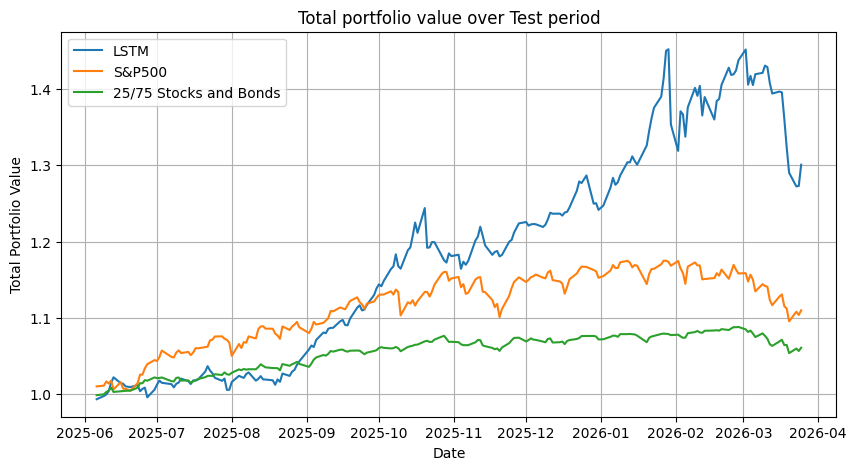

In [25]:
# rectangular shape:
plt.figure(figsize=(10,5))
plt.plot(df_test['date'][seq_len:], cum_growth, label='LSTM')
plt.plot(df_test['date'][seq_len:], cum_sp500, label='S&P500')
plt.plot(df_test['date'][seq_len:], cum_bench, label='25/75 Stocks and Bonds')
plt.xlabel("Date")
plt.ylabel("Total Portfolio Value")
plt.title("Total portfolio value over Test period")
plt.legend()
plt.grid(True)
plt.show()